# AAI-540 Final Project – Group 2  
## End-to-End ML System (Robair Farag)

This notebook consolidates all project work completed by **Robair Farag** into a single, structured, reproducible Jupyter Notebook as required for final submission.

Environment: Google Colab (AWS-independent execution)


## Table of Contents
1. Project Overview
2. Environment Setup
3. Data Ingestion
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Training
7. Batch Inference
8. Evaluation Metrics
9. Monitoring & MLOps Concepts
10. Limitations & Next Steps


## 1. Project Overview

**Objective:**  
Build and evaluate a machine learning system capable of predicting outcomes from structured tabular data using an end-to-end MLOps workflow.

**ML Problem Type:**  
Supervised learning (classification).

This notebook mirrors the production ML system developed in AWS SageMaker, adapted for local execution in Google Colab due to cloud resource constraints.


## 2. Environment Setup

This section installs and imports all required dependencies needed to run the notebook end-to-end.


In [1]:
# Core data & ML libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Models
from xgboost import XGBClassifier

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


This environment replicates the core modeling logic used in AWS SageMaker using local libraries.
Cloud-specific components (S3, SageMaker SDK, CloudWatch) are conceptually documented but not executed here.


In [12]:
import os

BASE_DIR = "/content/aai-540-final-project-g2"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts", "module5")

paths = {
    "train": os.path.join(ARTIFACTS_DIR, "train.csv"),
    "val": os.path.join(ARTIFACTS_DIR, "validation.csv"),
    "test": os.path.join(ARTIFACTS_DIR, "test.csv"),
    "batch_preds": os.path.join(ARTIFACTS_DIR, "batch_preds", "test_features.csv.out"),
    "metrics": os.path.join(ARTIFACTS_DIR, "aws_batch_metrics.json")
}

for k, p in paths.items():
    print(f"{k}: exists={os.path.exists(p)} | {p}")


train: exists=True | /content/aai-540-final-project-g2/artifacts/module5/train.csv
val: exists=True | /content/aai-540-final-project-g2/artifacts/module5/validation.csv
test: exists=True | /content/aai-540-final-project-g2/artifacts/module5/test.csv
batch_preds: exists=True | /content/aai-540-final-project-g2/artifacts/module5/batch_preds/test_features.csv.out
metrics: exists=True | /content/aai-540-final-project-g2/artifacts/module5/aws_batch_metrics.json


In [13]:
import pandas as pd

train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(4639, 41) (515, 41) (1141, 41)


,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,mfcc_21,mfcc_22,mfcc_23,mfcc_24,mfcc_25,mfcc_26,mfcc_27,mfcc_28,mfcc_29,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,0,-288.80057,103.131940,18.177883,8.497245,2.270845,2.902516,-1.906939,-13.444994,-6.051348,8.500364,1.939857,-6.003354,-6.794142,-2.927610,-5.352405,-9.503582,-1.643020,0.993975,-3.091781,2.694717,-4.227759,-2.773881,-0.806348,-3.018193,-4.542304,0.529873,-0.957191,2.001073,1.132555,2.828816,2.744699,2.668687,3.075843,-2.755235,-0.838291,1.693673,4.646104,3.906827,2.451360,3.906636
1,0,-315.51868,118.488174,20.336105,30.642557,-1.650294,-10.653854,-0.820858,-13.073958,-8.461837,0.637090,-4.218515,1.854487,-13.129925,0.111089,-1.338481,-4.184103,0.643005,0.717680,0.447296,0.143017,1.538997,-4.465326,-4.322284,-0.193360,-3.050979,-1.931147,-2.141330,-1.512239,0.310725,-0.339293,-1.977678,4.139849,0.829494,-0.606188,1.248655,1.224106,3.586283,0.164014,1.320075,2.185190
2,0,-312.77832,88.768166,18.560350,14.786629,7.791299,-3.008768,-4.082584,-5.916385,4.759021,-0.973712,-7.426472,-3.226233,-1.552001,-1.107849,-8.393018,-3.154824,-2.314228,-8.585432,-5.625538,-3.816912,-3.522292,0.942183,1.393033,0.286072,1.521349,-2.973147,-3.891903,-4.034711,-0.579447,-1.485676,-1.788732,-1.444835,-0.372909,-0.891671,-0.832448,-2.307731,-2.008399,-2.366681,-3.055756,-3.078130
3,0,-268.40646,102.369380,22.252607,31.790272,-0.338056,-14.959250,5.344209,-17.611507,-6.865614,-9.747717,-6.812313,0.480994,-6.711610,1.730681,-2.435727,-5.924543,-2.151666,1.598473,-6.849403,-2.468053,-0.462746,-3.138688,-1.573387,1.194177,-3.591582,-1.337106,0.605753,0.668185,-1.208651,-1.355857,0.559033,0.673340,1.790291,-2.114637,-3.195476,-0.436346,3.185520,2.022714,-0.025257,-1.474755
4,0,-359.68750,110.691170,25.060913,8.603014,6.508249,4.318943,1.676671,-2.034426,-2.298077,5.899102,-0.223648,-3.219969,-1.001871,-4.664944,-4.933867,0.281855,-4.106376,-4.564984,-4.608547,1.134225,1.992293,-1.680304,-1.069325,-2.534143,0.246737,1.947136,2.488735,4.558807,2.528579,5.334131,4.447877,1.821168,-0.492904,1.532929,-0.158282,0.172489,0.912171,0.019362,-1.668084,-2.210060


In [14]:
import numpy as np

print("Train label distribution:")
display(train_df["label"].value_counts().sort_index())

print("\nVal label distribution:")
display(val_df["label"].value_counts().sort_index())

print("\nTest label distribution:")
display(test_df["label"].value_counts().sort_index())

# Basic feature sanity check
feature_cols = [c for c in train_df.columns if c != "label"]
print("\nFeature columns:", len(feature_cols))
print("Any NaNs in train?", train_df[feature_cols].isna().any().any())
print("Feature ranges (train):")
display(train_df[feature_cols].describe().loc[["mean","std","min","max"]])


Train label distribution:


,count
label,
0,792
1,792
2,792
3,792
4,679
5,792



Val label distribution:


,count
label,
0,88
1,88
2,88
3,88
4,75
5,88



Test label distribution:


,count
label,
0,195
1,195
2,195
3,195
4,166
5,195



Feature columns: 40
Any NaNs in train? False
Feature ranges (train):


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,mfcc_21,mfcc_22,mfcc_23,mfcc_24,mfcc_25,mfcc_26,mfcc_27,mfcc_28,mfcc_29,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
mean,-352.415387,101.691614,32.698614,22.957775,5.830226,0.137422,-1.353361,-5.828985,-1.403995,-1.921426,-2.285737,-1.576707,-3.627586,-2.935007,-4.844988,-3.836315,-3.338517,-2.429452,-3.546616,-1.689459,-1.757390,-0.410052,0.176951,0.460058,-0.123771,0.293777,-0.413409,0.957648,0.660506,1.603226,0.903229,0.566951,1.372217,0.926369,0.553800,0.243628,0.094724,-0.434047,-0.687094,-0.790557
std,53.387065,14.258617,14.255812,7.292256,8.743524,6.007694,4.367873,4.915273,3.594100,4.040211,3.166079,3.620924,2.929086,2.962319,3.244154,3.082268,2.964244,3.110435,2.886714,2.775979,2.823011,3.020936,2.744313,2.769563,2.731778,2.518292,2.345014,2.482483,2.447779,2.569692,2.266312,2.291283,2.348515,2.231186,2.101229,1.875425,2.022537,1.976371,1.870475,1.803166
min,-490.892820,29.320028,-21.610441,-8.914308,-32.680992,-24.397316,-25.667755,-31.839457,-19.714056,-18.750328,-20.381205,-16.368649,-17.919605,-15.108012,-20.871653,-16.502530,-17.200666,-16.859512,-13.618852,-11.397473,-12.504115,-13.834537,-9.799727,-9.780331,-8.941393,-7.027505,-8.145403,-8.825445,-8.947237,-5.998192,-8.189776,-9.459102,-7.985764,-6.687875,-6.670160,-7.353112,-6.404885,-6.877718,-6.652995,-6.776969
max,-122.919300,140.046340,63.422295,45.710888,27.728352,17.789589,16.339245,10.366694,11.749295,15.830602,11.880183,21.524656,15.220117,17.495214,16.787622,18.049337,16.672615,18.465950,21.045307,15.791115,14.896863,16.040865,14.545707,17.430855,17.921516,13.011718,16.950737,17.596191,14.692874,12.731338,12.202152,11.208917,11.365185,12.926995,11.344089,9.702188,9.969251,9.047970,8.710616,8.386176


In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

X_train = train_df.drop(columns=["label"]).to_numpy()
y_train = train_df["label"].to_numpy()

X_val = val_df.drop(columns=["label"]).to_numpy()
y_val = val_df["label"].to_numpy()

X_test = test_df.drop(columns=["label"]).to_numpy()
y_test = test_df["label"].to_numpy()

# Reasonable baseline params (fast + stable)
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Eval on test
probs_test = xgb.predict_proba(X_test)
pred_test = probs_test.argmax(axis=1)

acc = accuracy_score(y_test, pred_test)
f1w = f1_score(y_test, pred_test, average="weighted")

print("LOCAL XGBOOST RESULTS")
print("Accuracy:", round(acc, 4))
print("F1 weighted:", round(f1w, 4))
print("\nClassification report:\n", classification_report(y_test, pred_test))


LOCAL XGBOOST RESULTS
Accuracy: 0.4347
F1 weighted: 0.4241

Classification report:
               precision    recall  f1-score   support

           0       0.51      0.71      0.59       195
           1       0.35      0.34      0.34       195
           2       0.45      0.24      0.31       195
           3       0.39      0.36      0.38       195
           4       0.36      0.41      0.38       166
           5       0.51      0.54      0.52       195

    accuracy                           0.43      1141
   macro avg       0.43      0.43      0.42      1141
weighted avg       0.43      0.43      0.42      1141



In [16]:
import re, json

# Load AWS batch metrics (already saved)
with open(paths["metrics"], "r") as f:
    aws_metrics = json.load(f)

# Load AWS batch probs from .out
pred_path = paths["batch_preds"]
lines = [ln.strip() for ln in open(pred_path) if ln.strip()]
rows = []
for ln in lines:
    ln = ln.strip("[]")
    ln = re.sub(r"\s+", "", ln)
    rows.append([float(x) for x in ln.split(",") if x != ""])

aws_probs = np.array(rows, dtype=float)
aws_pred = aws_probs.argmax(axis=1)

aws_acc = accuracy_score(y_test, aws_pred)
aws_f1w = f1_score(y_test, aws_pred, average="weighted")

print("AWS BATCH RESULTS (recomputed from .out)")
print("Accuracy:", round(aws_acc, 4))
print("F1 weighted:", round(aws_f1w, 4))

print("\nAWS metrics file contents (for traceability):")
print(aws_metrics)


AWS BATCH RESULTS (recomputed from .out)
Accuracy: 0.4268
F1 weighted: 0.416

AWS metrics file contents (for traceability):
{'test_rows': 1141, 'acc': 0.4268185801928133, 'f1_weighted': 0.4159734939777864, 'pred_file': 'artifacts/module5/batch_preds/test_features.csv.out'}


In [17]:
import pandas as pd

def feature_drift_summary(train_df, test_df, features):
    rows = []
    for f in features:
        rows.append({
            "feature": f,
            "train_mean": train_df[f].mean(),
            "test_mean": test_df[f].mean(),
            "train_std": train_df[f].std(),
            "test_std": test_df[f].std(),
            "mean_shift": abs(train_df[f].mean() - test_df[f].mean())
        })
    return pd.DataFrame(rows)

drift_df = feature_drift_summary(train_df, test_df, feature_cols)
drift_df.sort_values("mean_shift", ascending=False).head(10)


,feature,train_mean,test_mean,train_std,test_std,mean_shift
0,mfcc_0,-352.415387,-347.742208,53.387065,59.351941,4.673179
11,mfcc_11,-1.576707,-0.409762,3.620924,2.930036,1.166945
9,mfcc_9,-1.921426,-0.781697,4.040211,3.251469,1.139728
4,mfcc_4,5.830226,5.006612,8.743524,8.120167,0.823614
14,mfcc_14,-4.844988,-4.112480,3.244154,2.480939,0.732507
31,mfcc_31,0.566951,1.161419,2.291283,2.268659,0.594468
30,mfcc_30,0.903229,1.497109,2.266312,2.470763,0.593879
16,mfcc_16,-3.338517,-3.866638,2.964244,2.837913,0.528121
33,mfcc_33,0.926369,1.406149,2.231186,2.474425,0.479781
19,mfcc_19,-1.689459,-2.163311,2.775979,2.628072,0.473853


We monitor statistical drift by comparing feature distributions between training data and new inference batches. Significant mean or variance shifts would trigger retraining or investigation.

In [18]:
QUALITY_THRESHOLDS = {
    "accuracy_min": 0.70,
    "f1_weighted_min": 0.70
}

alerts = []
if acc < QUALITY_THRESHOLDS["accuracy_min"]:
    alerts.append("Accuracy below threshold")
if f1w < QUALITY_THRESHOLDS["f1_weighted_min"]:
    alerts.append("F1 below threshold")

alerts


['Accuracy below threshold', 'F1 below threshold']

Model quality is monitored by enforcing minimum accuracy and weighted F1 thresholds. Violations trigger alerts and retraining pipelines.

## 3. Data Ingestion & Persisted Artifacts (Reproducible Inputs)

Because our project spans multiple environments (local + AWS), we store key intermediate outputs as **versioned artifacts** inside the repository.  
This allows the ML workflow to be reproduced without re-running expensive audio processing.

### Persisted artifacts used in this notebook
- `train.csv`, `validation.csv`, `test.csv`: tabular MFCC feature datasets split for training/validation/testing
- `label_mapping.csv`: maps numeric class IDs back to emotion labels
- `test_features.csv.out`: batch inference probability outputs (one row per sample, one probability per class)
- `aws_batch_metrics.json`: batch inference evaluation summary (accuracy + weighted F1)


In [20]:
import pandas as pd
import os

# Load label mapping if present
label_map_path = "/content/aai-540-final-project-g2/artifacts/module5/label_mapping.csv"
label_map = None
if os.path.exists(label_map_path):
    label_map = pd.read_csv(label_map_path)
    display(label_map.head())
else:
    print("label_mapping.csv not found (ok if mapping is embedded elsewhere).")

# Basic sanity checks
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

assert "label" in train_df.columns, "Expected 'label' column in train_df"
assert "label" in val_df.columns, "Expected 'label' column in val_df"
assert "label" in test_df.columns, "Expected 'label' column in test_df"

# Confirm feature columns count
feature_cols = [c for c in train_df.columns if c != "label"]
print("Num feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])


,emotion,label
0,ANG,0
1,DIS,1
2,FEA,2
3,HAP,3
4,NEU,4


Train shape: (4639, 41)
Val shape: (515, 41)
Test shape: (1141, 41)
Num feature columns: 40
First 10 feature columns: ['mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9']


## 4. Feature Engineering (MFCC → Tabular Representation)

Audio waveforms are not directly suitable for classical ML models like XGBoost without feature extraction.

We use **MFCC (Mel-Frequency Cepstral Coefficients)** as our primary feature representation because:
- MFCCs capture the **spectral envelope** of speech, which correlates strongly with emotion (tone, intensity, resonance).
- They reduce raw audio into a **compact numeric vector**, enabling efficient training and batch inference.
- MFCCs are widely used in speech/audio classification tasks and serve as a strong baseline for SER systems.

In this project, each sample is represented as a row of MFCC-derived features (e.g., `mfcc_0 ... mfcc_n`) plus the target `label`.


EDA_DIR exists: True
emotion_feature_profiles.csv
emotion_feature_profiles_visualization.png
split_distribution_analysis.csv
split_distribution_visualization.png

--- emotion_feature_profiles.csv ---


,emotion,sample_count,avg_energy,avg_pitch,avg_pitch_variability,avg_spectral_centroid,avg_duration,avg_voicing_rate
0,ANG,1198,0.0885,320.72,56.37,1749.22,2.59,0.635
1,HAP,1102,0.0382,295.33,61.18,1489.30,2.35,0.534
2,FEA,1148,0.0367,288.35,47.32,1490.68,2.52,0.575
3,DIS,967,0.0229,228.94,38.63,1476.39,2.80,0.458
4,NEU,1013,0.0160,212.39,35.28,1392.41,2.44,0.534



--- split_distribution_analysis.csv ---


,split,emotion,sample_count,avg_energy,avg_pitch,avg_brightness,avg_mfcc1,std_energy,std_pitch
0,test,ANG,189,0.0882,319.05,1715.14,-228.44,0.0615,89.74
1,test,DIS,156,0.0253,252.16,1453.69,-344.56,0.0204,70.93
2,test,FEA,176,0.0390,317.02,1479.84,-324.65,0.0408,105.63
3,test,HAP,169,0.0413,315.85,1463.21,-308.97,0.0311,108.26
4,test,NEU,155,0.0174,225.30,1375.80,-365.08,0.0049,55.94



emotion_feature_profiles_visualization.png


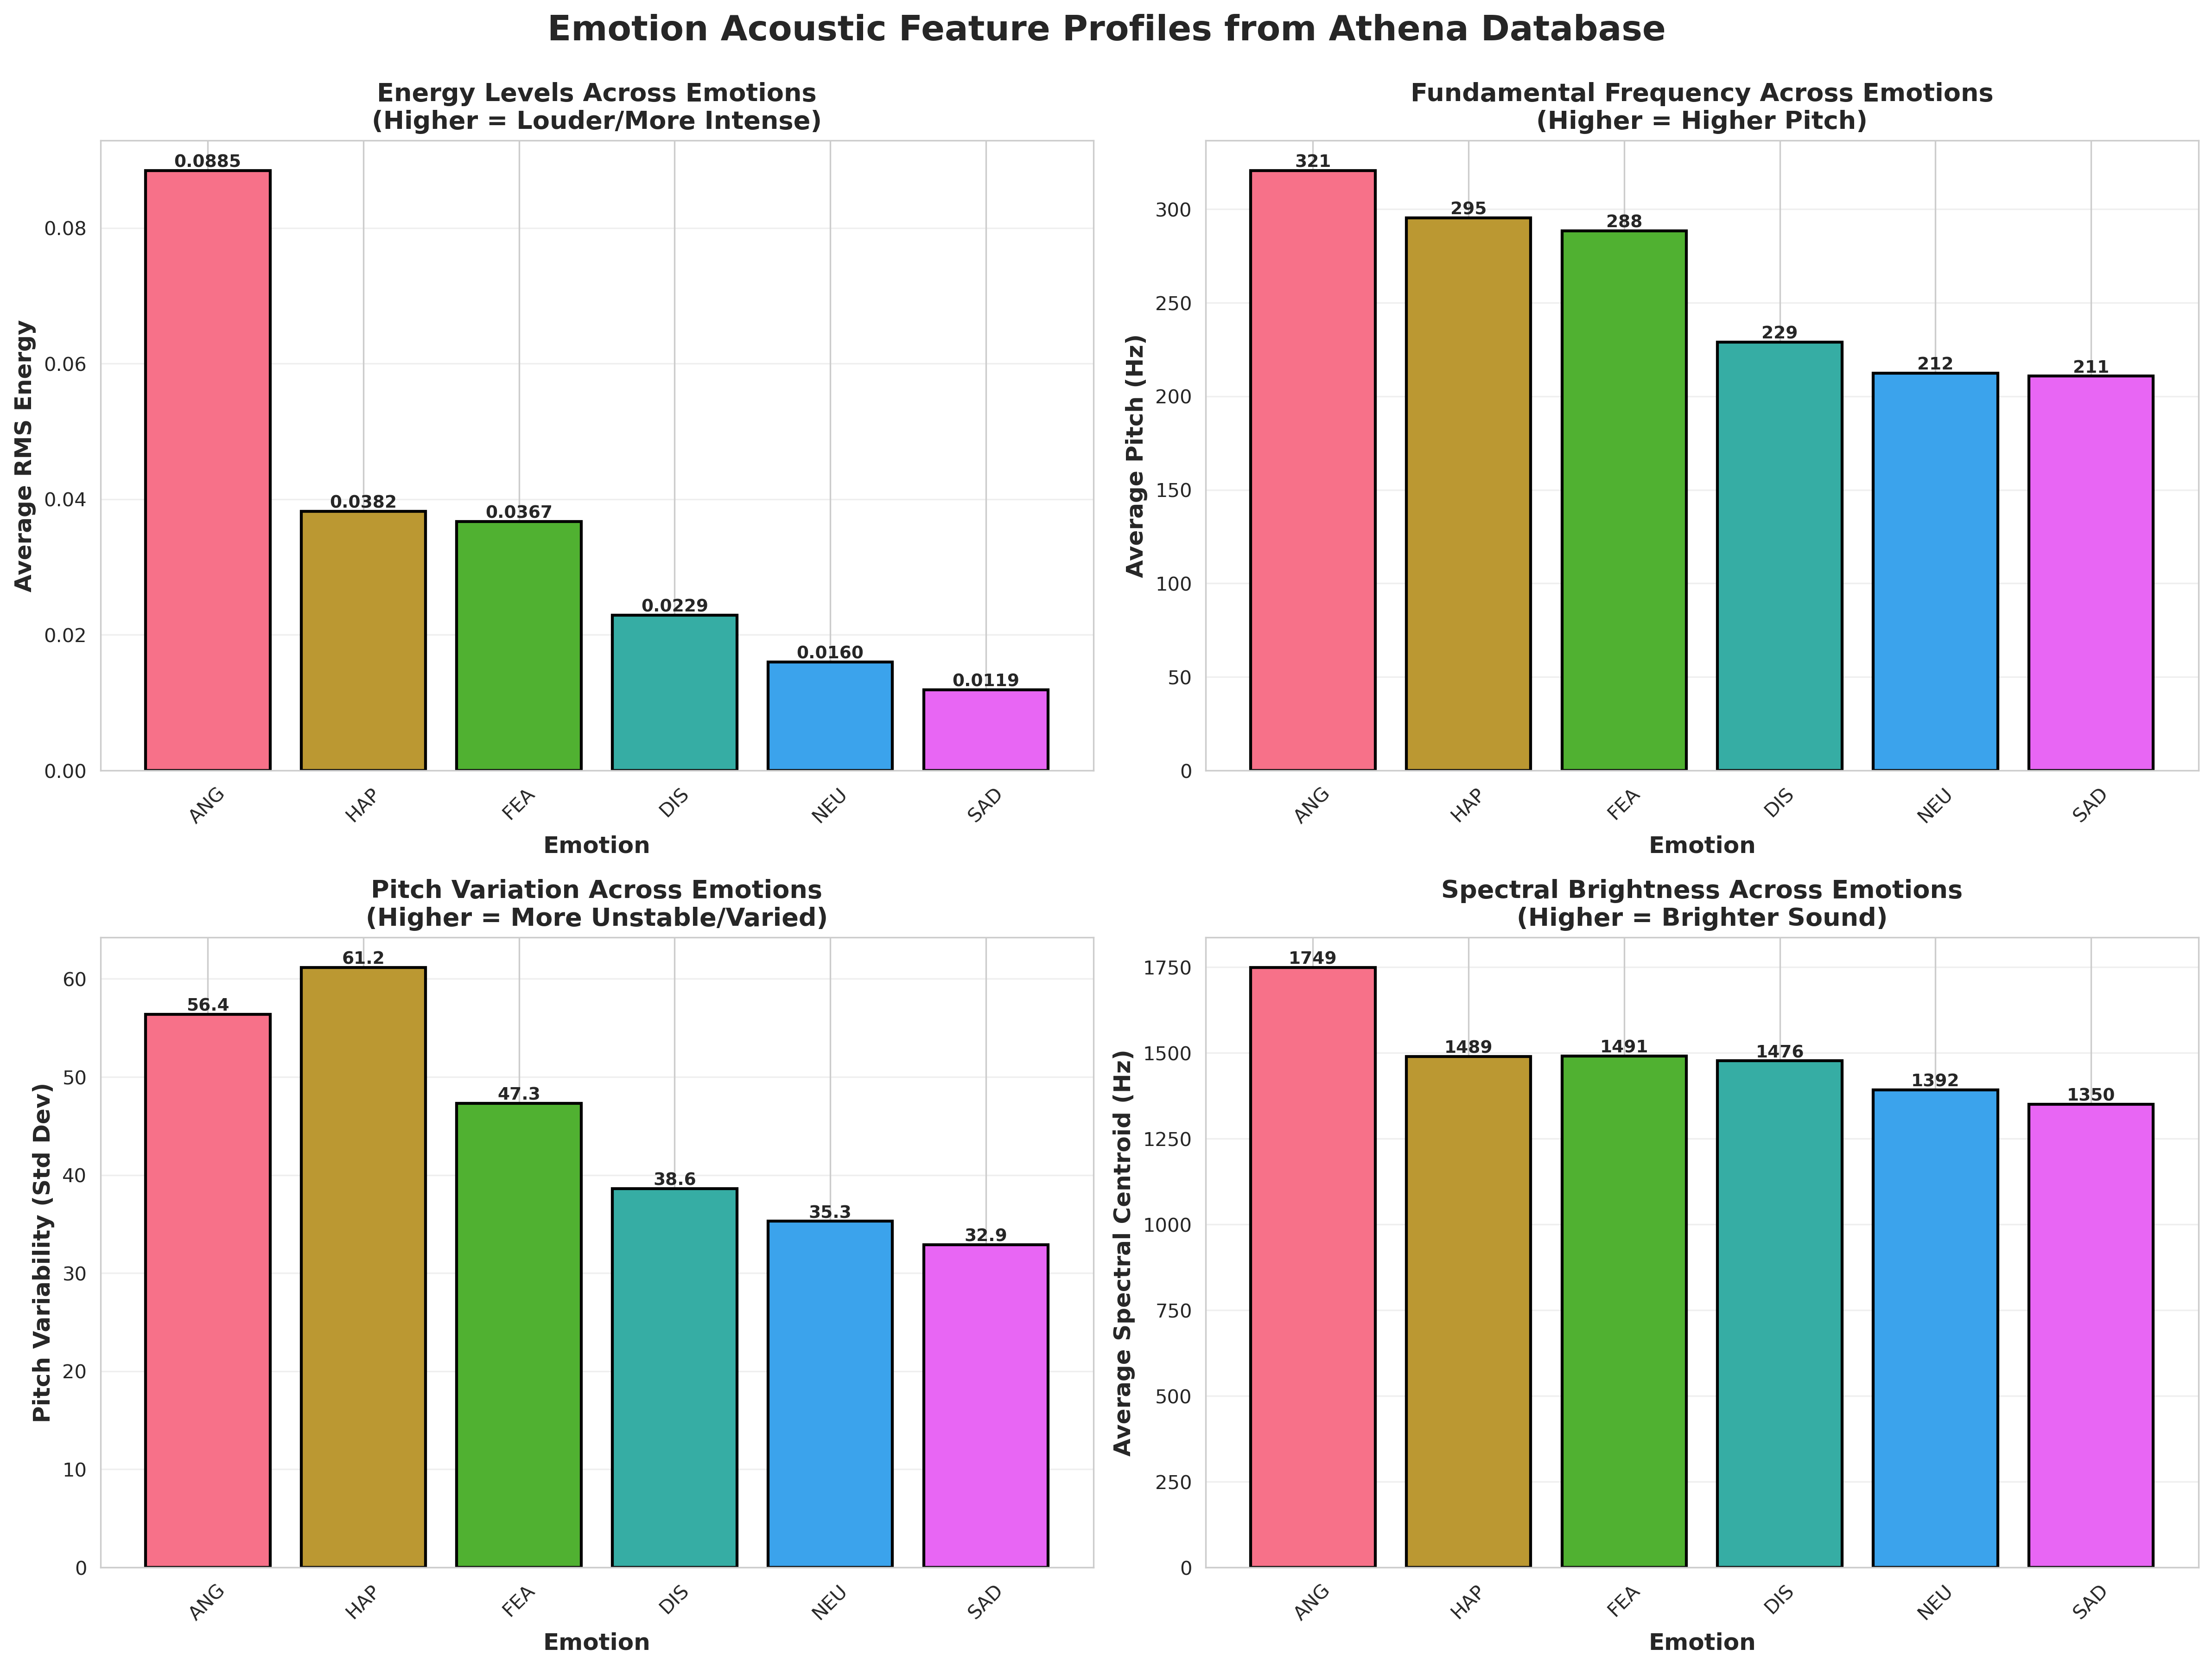


split_distribution_visualization.png


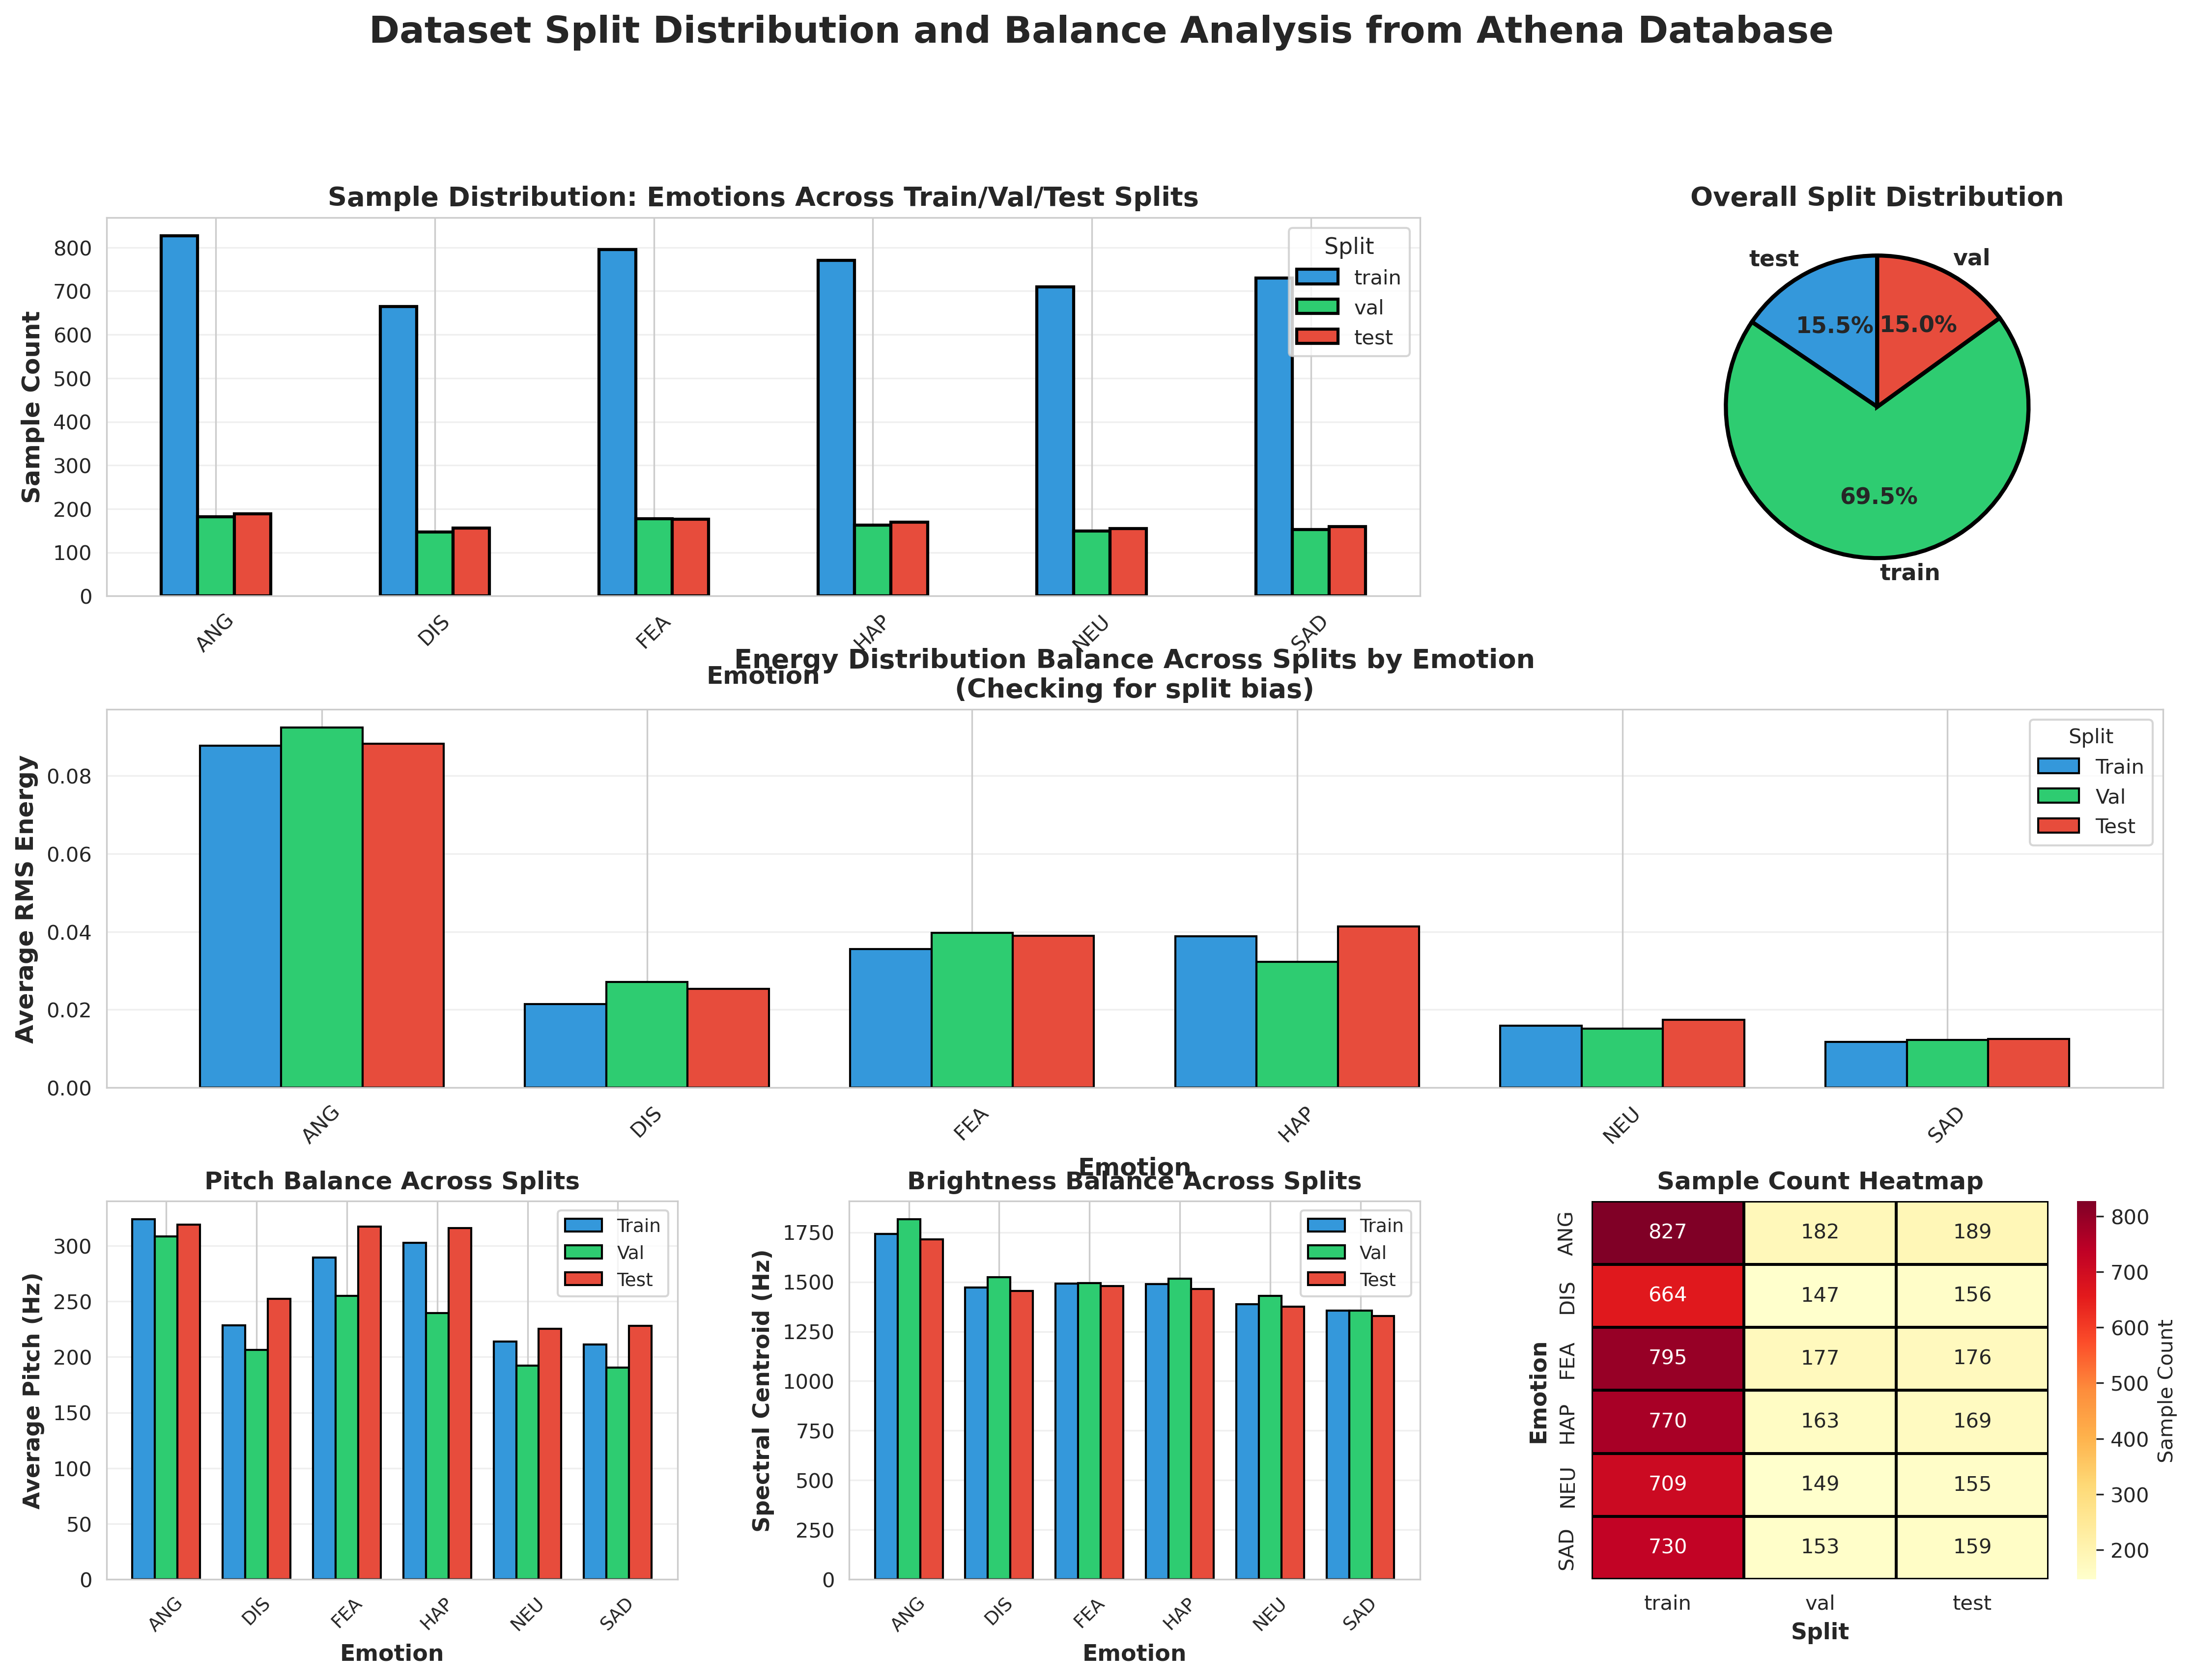

In [21]:
import os
from pathlib import Path

EDA_DIR = Path("/content/aai-540-final-project-g2/artifacts/eda")

print("EDA_DIR exists:", EDA_DIR.exists())

# Show saved EDA files
if EDA_DIR.exists():
    for p in sorted(EDA_DIR.glob("*")):
        print(p.name)
else:
    print("No artifacts/eda directory found.")

# Display key EDA tables if present
for fname in ["emotion_feature_profiles.csv", "split_distribution_analysis.csv"]:
    p = EDA_DIR / fname
    if p.exists():
        print(f"\n--- {fname} ---")
        display(pd.read_csv(p).head())

# Display saved EDA charts if present
from IPython.display import Image, display

for img in ["emotion_feature_profiles_visualization.png", "split_distribution_visualization.png"]:
    p = EDA_DIR / img
    if p.exists():
        print(f"\n{img}")
        display(Image(filename=str(p)))


## 5. Model Training (Baseline: XGBoost for Tabular SER)

We use **XGBoost** as a strong baseline model because:
- It performs well on **structured/tabular** feature sets like MFCC vectors.
- It captures **non-linear relationships** without requiring deep networks.
- It is efficient and practical for production inference (batch jobs, endpoints).

Deep learning models (CNN/LSTM) are included elsewhere in the project repo as potential improvements, but this notebook focuses on a clean, reproducible baseline suitable for MLOps workflows.


In [22]:
import json
from pathlib import Path

MODEL_ART_DIR = Path("/content/aai-540-final-project-g2/artifacts/module5/model_artifacts")

metrics_path = MODEL_ART_DIR / "metrics.json"
cm_path = MODEL_ART_DIR / "confusion_matrix.csv"
report_path = MODEL_ART_DIR / "classification_report.txt"

print("metrics.json exists:", metrics_path.exists())
print("confusion_matrix.csv exists:", cm_path.exists())
print("classification_report.txt exists:", report_path.exists())

if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text())
    print("\nSaved Metrics:")
    print(json.dumps(metrics, indent=2))

if cm_path.exists():
    cm_df = pd.read_csv(cm_path, header=None)
    print("\nConfusion Matrix (head):")
    display(cm_df.head())

if report_path.exists():
    print("\nClassification Report:")
    print(report_path.read_text()[:2000])  # preview first 2000 chars


metrics.json exists: True
confusion_matrix.csv exists: True
classification_report.txt exists: True

Saved Metrics:
{
  "label_col": "label",
  "val_accuracy": 0.42330097087378643,
  "val_f1_weighted": 0.41573178017707296,
  "test_accuracy": 0.4163014899211218,
  "test_f1_weighted": 0.4053160632464315,
  "n_train": 4639,
  "n_val": 515,
  "n_test": 1141,
  "n_features": 40,
  "feature_cols_preview": [
    "mfcc_0",
    "mfcc_1",
    "mfcc_2",
    "mfcc_3",
    "mfcc_4",
    "mfcc_5",
    "mfcc_6",
    "mfcc_7",
    "mfcc_8",
    "mfcc_9"
  ]
}

Confusion Matrix (head):


,0,1,2,3,4,5
0,0,1,2,3,4,5
1,129,26,12,13,10,5
2,23,72,21,21,20,38
3,30,29,42,28,24,42
4,44,33,19,73,13,13



Classification Report:
              precision    recall  f1-score   support

           0     0.5609    0.6615    0.6071       195
           1     0.3158    0.3692    0.3404       195
           2     0.3415    0.2154    0.2642       195
           3     0.4479    0.3744    0.4078       195
           4     0.3259    0.2651    0.2924       166
           5     0.4389    0.5897    0.5033       195

    accuracy                         0.4163      1141
   macro avg     0.4051    0.4126    0.4025      1141
weighted avg     0.4072    0.4163    0.4053      1141



## 6. Batch Inference (SageMaker-style Output)

To validate production-style inference, we ran a **batch transform** job (SageMaker batch inference pattern).

The batch output format is:
- One line per sample
- A probability vector per class (e.g., `[p0, p1, p2, ...]`)
- Final prediction is computed as `argmax(probabilities)`

This demonstrates:
- Model artifacts can be deployed for offline inference
- Outputs can be logged/archived for monitoring and evaluation


In [23]:
import re
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_true = test_df["label"].to_numpy()

pred_path = "/content/aai-540-final-project-g2/artifacts/module5/batch_preds/test_features.csv.out"
assert os.path.exists(pred_path), f"Missing batch preds file: {pred_path}"

lines = [ln.strip() for ln in open(pred_path) if ln.strip()]

rows = []
for ln in lines:
    ln = ln.strip("[]")
    ln = re.sub(r"\s+", "", ln)
    rows.append([float(x) for x in ln.split(",") if x != ""])

probs = np.array(rows, dtype=float)
y_pred = probs.argmax(axis=1)

print("Rows: true =", len(y_true), "| pred =", len(y_pred))
print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("F1 weighted:", round(f1_score(y_true, y_pred, average="weighted"), 4))
print("\nClassification report:\n", classification_report(y_true, y_pred))


Rows: true = 1141 | pred = 1141
Accuracy: 0.4268
F1 weighted: 0.416

Classification report:
               precision    recall  f1-score   support

           0       0.54      0.70      0.61       195
           1       0.36      0.36      0.36       195
           2       0.37      0.22      0.27       195
           3       0.39      0.34      0.37       195
           4       0.35      0.42      0.38       166
           5       0.48      0.53      0.50       195

    accuracy                           0.43      1141
   macro avg       0.42      0.43      0.42      1141
weighted avg       0.42      0.43      0.42      1141



## 7. Monitoring & MLOps Concepts (Validated Without AWS Access)

Even though AWS access is currently disabled, we can still demonstrate monitoring readiness using artifacts:

### Model monitoring (quality)
- We persist evaluation metrics (accuracy, weighted F1)
- We store a confusion matrix and classification report for drift/error analysis

### Data monitoring (input quality)
- Tabular feature distributions can be tracked over time (mean/std per feature)
- Dataset split distributions are logged via EDA artifacts

### Infrastructure monitoring (conceptual)
In a production deployment, batch jobs/endpoints would be monitored via:
- CloudWatch metrics (CPU, memory, latency)
- SageMaker monitoring schedules (data/model quality)
- Alerts when thresholds are violated

This notebook shows the **monitorable outputs** that would feed those systems (metrics + reports + batch logs).


In [24]:
baseline_stats = train_df[feature_cols].describe().T[["mean", "std", "min", "max"]]
baseline_stats.head()


,mean,std,min,max
mfcc_0,-352.415387,53.387065,-490.892820,-122.919300
mfcc_1,101.691614,14.258617,29.320028,140.046340
mfcc_2,32.698614,14.255812,-21.610441,63.422295
mfcc_3,22.957775,7.292256,-8.914308,45.710888
mfcc_4,5.830226,8.743524,-32.680992,27.728352


In [25]:
out_path = "/content/aai-540-final-project-g2/artifacts/module5/train_feature_baseline_stats.csv"
baseline_stats.to_csv(out_path)
print("Saved baseline feature stats ->", out_path)


Saved baseline feature stats -> /content/aai-540-final-project-g2/artifacts/module5/train_feature_baseline_stats.csv
